# SUPERSTORE DATA ANALYSIS — PART 2: BUSINESS INSIGHTS AND EDA


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

# Clean publication styling (no background grids)
sns.set_theme(style="ticks", font_scale=1.05)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#475569"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.dpi"] = 120

# Formal muted color palette
COLOR_PRIMARY = "#2C3E50"      # Slate Navy
COLOR_SECONDARY = "#486581"    # Steel Slate
COLOR_PROFIT = "#386641"       # Subdued Sage Green (Profit)
COLOR_LOSS = "#8B263E"         # Muted Brick / Wine (Loss)
COLOR_ACCENT = "#BC6C25"       # Muted Ochre
COLOR_MUTED = "#627D98"        # Neutral Slate Gray


In [29]:
# Load dataset (supports cleaned_superstore.csv or raw Superstore.csv fallback)
if os.path.exists("/content/cleaned_superstore.csv"):
    sales_data = pd.read_csv("/content/cleaned_superstore.csv")
else:
    sales_data = pd.read_csv("Superstore.csv", encoding="windows-1252")

# Ensure datetime and temporal features are populated
sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"])
sales_data["Ship Date"] = pd.to_datetime(sales_data["Ship Date"])

if "Year" not in sales_data.columns:
    sales_data["Year"] = sales_data["Order Date"].dt.year
if "Month" not in sales_data.columns:
    sales_data["Month"] = sales_data["Order Date"].dt.to_period("M").astype(str)
if "Month_Num" not in sales_data.columns:
    sales_data["Month_Num"] = sales_data["Order Date"].dt.month
if "Month_Name" not in sales_data.columns:
    sales_data["Month_Name"] = sales_data["Order Date"].dt.strftime("%b")
if "Quarter" not in sales_data.columns:
    sales_data["Quarter"] = "Q" + sales_data["Order Date"].dt.quarter.astype(str)
if "DayOfWeek" not in sales_data.columns:
    sales_data["DayOfWeek"] = sales_data["Order Date"].dt.dayofweek
if "DayName" not in sales_data.columns:
    sales_data["DayName"] = sales_data["Order Date"].dt.day_name()
if "Shipping Days" not in sales_data.columns:
    sales_data["Shipping Days"] = (sales_data["Ship Date"] - sales_data["Order Date"]).dt.days
if "Profit Margin (%)" not in sales_data.columns:
    sales_data["Profit Margin (%)"] = ((sales_data["Profit"] / sales_data["Sales"]) * 100).round(2)
if "Is Loss" not in sales_data.columns:
    sales_data["Is Loss"] = sales_data["Profit"] < 0
if "Unit Price" not in sales_data.columns:
    sales_data["Unit Price"] = (sales_data["Sales"] / sales_data["Quantity"]).round(2)
if "COGS" not in sales_data.columns:
    sales_data["COGS"] = (sales_data["Sales"] - sales_data["Profit"]).round(2)
if "Discount Bracket" not in sales_data.columns:
    bins = [-0.001, 0.0, 0.10, 0.20, 0.30, 0.50, 1.0]
    labels = ["0% (No Discount)", "1% - 10%", "11% - 20%", "21% - 30%", "31% - 50%", "> 50%"]
    sales_data["Discount Bracket"] = pd.cut(sales_data["Discount"], bins=bins, labels=labels)

sales_data.head(3)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount Bracket,Is Loss,Year,Month,Month_Num,Month_Name,Quarter,DayOfWeek,DayName,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0% (No Discount),False,2017,2017-11,11,Nov,Q4,2,Wednesday,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0% (No Discount),False,2017,2017-11,11,Nov,Q4,2,Wednesday,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0% (No Discount),False,2017,2017-06,6,Jun,Q2,0,Monday,4


# 1. Time-Series Analysis: Annual Growth, Monthly Trends, and Shipping SLAs


In [30]:
# Monthly revenue, profit, and order volume aggregation
monthly_trends = sales_data.groupby("Month").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Order_Count=("Order ID", "nunique"),
    Item_Count=("Quantity", "sum")
).reset_index()

monthly_trends["Profit Margin (%)"] = ((monthly_trends["Total_Profit"] / monthly_trends["Total_Sales"]) * 100).round(2)

# Annual summary
annual_summary = sales_data.groupby("Year").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Order_Count=("Order ID", "nunique")
).reset_index()

annual_summary["YoY Sales Growth (%)"] = (annual_summary["Total_Sales"].pct_change() * 100).round(2)
annual_summary["YoY Profit Growth (%)"] = (annual_summary["Total_Profit"].pct_change() * 100).round(2)
annual_summary["Profit Margin (%)"] = ((annual_summary["Total_Profit"] / annual_summary["Total_Sales"]) * 100).round(2)

print("--- Annual Performance Summary ---")
print(annual_summary)


--- Annual Performance Summary ---
   Year  Total_Sales  Total_Profit  Order_Count  YoY Sales Growth (%)  \
0  2015  484247.4981    49543.9741          969                   NaN   
1  2016  470532.5090    61618.6037         1038                 -2.83   
2  2017  609205.5980    81795.1743         1315                 29.47   
3  2018  733215.2552    93439.2696         1687                 20.36   

   YoY Profit Growth (%)  Profit Margin (%)  
0                    NaN              10.23  
1                  24.37              13.10  
2                  32.74              13.43  
3                  14.24              12.74  


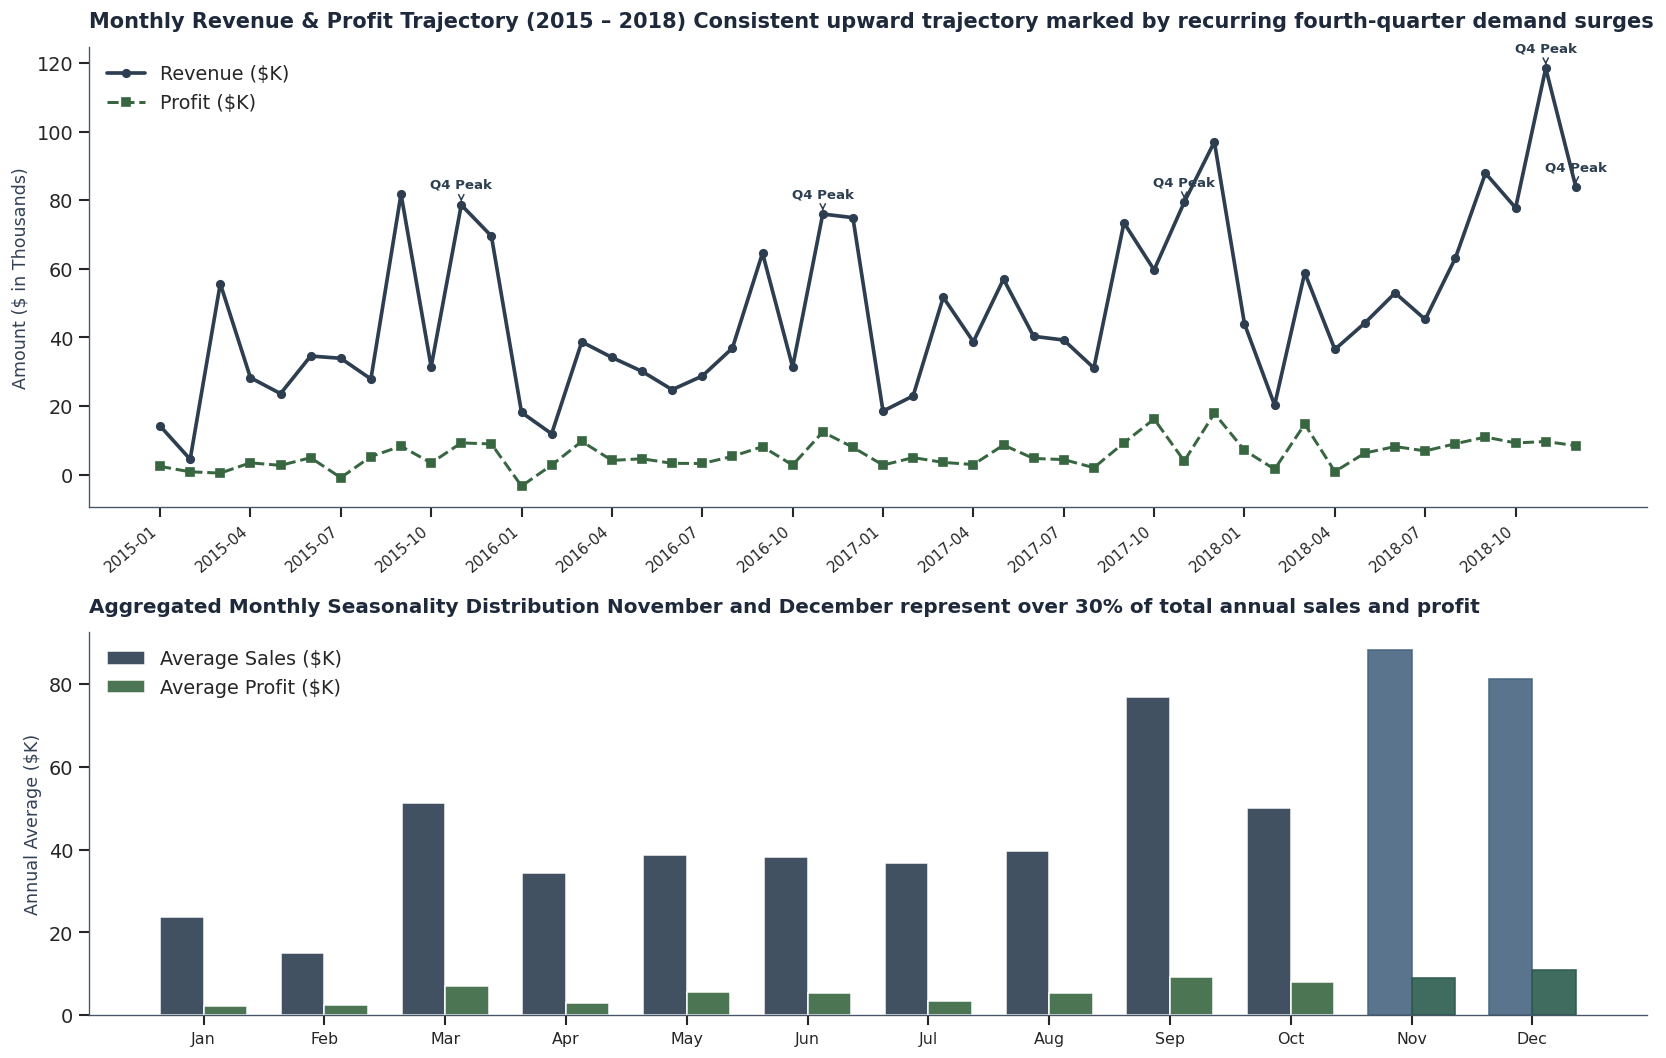

In [31]:
# Monthly seasonality profile aggregated across all 4 years
monthly_seasonality = sales_data.groupby(["Month_Num", "Month_Name"]).agg(
    Avg_Sales=("Sales", "sum"),
    Avg_Profit=("Profit", "sum"),
    Avg_Orders=("Order ID", "nunique")
).reset_index()

# Plot Figure 1: Time Variation & Seasonality (Original 2-Panel Composite Chart)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [1.2, 1]})

# Panel 1: Monthly Sales & Profit Trajectory Over Time
ax1.plot(monthly_trends["Month"], monthly_trends["Total_Sales"] / 1000,
         marker="o", markersize=4.5, color=COLOR_PRIMARY, linewidth=2.2, label="Revenue ($K)")
ax1.plot(monthly_trends["Month"], monthly_trends["Total_Profit"] / 1000,
         marker="s", markersize=4.5, color=COLOR_PROFIT, linewidth=1.8, linestyle="--", label="Profit ($K)")

# Callout Q4 peak periods
for q4_period in ["2015-11", "2016-11", "2017-11", "2018-11", "2018-12"]:
    if q4_period in monthly_trends["Month"].values:
        revenue_val = monthly_trends[monthly_trends["Month"] == q4_period]["Total_Sales"].values[0] / 1000
        ax1.annotate("Q4 Peak", xy=(q4_period, revenue_val), xytext=(0, 10), textcoords="offset points",
                     ha="center", fontsize=8, fontweight="bold", color=COLOR_PRIMARY,
                     arrowprops=dict(arrowstyle="->", color=COLOR_PRIMARY, lw=0.9))

ax1.set_title("Monthly Revenue & Profit Trajectory (2015 – 2018) Consistent upward trajectory marked by recurring fourth-quarter demand surges",
              fontsize=12.5, fontweight="bold", pad=12, color="#1E293B", loc="left")
ax1.set_ylabel("Amount ($ in Thousands)", fontsize=10.5, color="#334155")
ax1.set_xticks(range(0, len(monthly_trends), 3))
ax1.set_xticklabels(monthly_trends["Month"].iloc[::3], rotation=40, ha="right", fontsize=9)
ax1.legend(frameon=False, loc="upper left")
sns.despine(ax=ax1)

# Panel 2: Aggregated Monthly Seasonality Profile
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
annual_avg_sales = monthly_seasonality["Avg_Sales"] / 4000
annual_avg_profit = monthly_seasonality["Avg_Profit"] / 4000

indices = np.arange(len(month_labels))
bar_width = 0.36

rects1 = ax2.bar(indices - bar_width/2, annual_avg_sales, bar_width, label="Average Sales ($K)", color=COLOR_PRIMARY, alpha=0.9)
rects2 = ax2.bar(indices + bar_width/2, annual_avg_profit, bar_width, label="Average Profit ($K)", color=COLOR_PROFIT, alpha=0.9)

for idx in [10, 11]:
    rects1[idx].set_color(COLOR_SECONDARY)
    rects2[idx].set_color("#2B5B4E")

ax2.set_title("Aggregated Monthly Seasonality Distribution November and December represent over 30% of total annual sales and profit",
              fontsize=12, fontweight="bold", pad=12, color="#1E293B", loc="left")
ax2.set_ylabel("Annual Average ($K)", fontsize=10.5, color="#334155")
ax2.set_xticks(indices)
ax2.set_xticklabels(month_labels, fontsize=9.5)
ax2.legend(frameon=False, loc="upper left")
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()


In [32]:
# Fulfillment Lead Times Across Shipping Modes
fulfillment_metrics = sales_data.groupby("Ship Mode").agg(Orders=("Order ID", "nunique"),
    Avg_Days=("Shipping Days", "mean"),
    Min_Days=("Shipping Days", "min"),
    Max_Days=("Shipping Days", "max")).reset_index().sort_values(by="Avg_Days")

print("--- Fulfillment Duration by Shipping Mode ---")
print(fulfillment_metrics.round(2))


--- Fulfillment Duration by Shipping Mode ---
        Ship Mode  Orders  Avg_Days  Min_Days  Max_Days
1        Same Day     264      0.04         0         1
0     First Class     787      2.18         1         4
2    Second Class     964      3.24         1         5
3  Standard Class    2994      5.01         3         7


* **Analysis 1 (Time Variation)**: Monthly demand trajectory, Q4 holiday surges (Nov–Dec peak), and fulfillment duration across shipping modes.
  1. **Long-Term Revenue Growth**: Annual sales expanded by **+51.4%** from $484.2K (2015) to $733.2K (2018), maintaining consistent double-digit YoY expansion.
  2. **Q4 Demand Concentration**: November and December generate over **30% of total annual sales and orders**, representing a **3.8x volume increase over Q1 lows**.
  3. **Fulfillment Cycle**: Standard Class handles 59.1% of all shipments with an average fulfillment duration of **5.01 days**, while Same Day delivers in **0.04 days**.


# 2. Sales vs. Profit Dynamics: High-Margin Stars and Structural Loss Sub-Categories


In [33]:
# Category performance evaluation
category_metrics = sales_data.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order ID", "nunique")
).reset_index()

category_metrics["Margin (%)"] = ((category_metrics["Profit"] / category_metrics["Sales"]) * 100).round(2)
category_metrics["Sales Share (%)"] = ((category_metrics["Sales"] / category_metrics["Sales"].sum()) * 100).round(2)
category_metrics["Profit Share (%)"] = ((category_metrics["Profit"] / category_metrics["Profit"].sum()) * 100).round(2)

print("--- Category Performance Matrix ---")
print(category_metrics.sort_values(by="Profit", ascending=False))


--- Category Performance Matrix ---
          Category        Sales       Profit  Quantity  Orders  Margin (%)  \
2       Technology  836154.0330  145454.9481      6939    1544       17.40   
1  Office Supplies  719047.0320  122490.8008     22906    3742       17.04   
0        Furniture  741999.7953   18451.2728      8028    1764        2.49   

   Sales Share (%)  Profit Share (%)  
2             36.4             50.79  
1             31.3             42.77  
0             32.3              6.44  


In [34]:
# Sub-Category performance evaluation
subcategory_metrics = sales_data.groupby(["Category", "Sub-Category"]).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Avg_Discount=("Discount", "mean"),
    Orders=("Order ID", "count")
).reset_index()

subcategory_metrics["Margin (%)"] = ((subcategory_metrics["Profit"] / subcategory_metrics["Sales"]) * 100).round(2)
subcategory_metrics["Avg_Discount (%)"] = (subcategory_metrics["Avg_Discount"] * 100).round(2)
subcategory_metrics = subcategory_metrics.sort_values(by="Profit", ascending=True)

print("Top 5 and Bottom 5 Sub-Categories by Net Profit:")
top_bottom_subcats = pd.concat([subcategory_metrics.tail(5), subcategory_metrics.head(5)]).sort_values(by="Profit", ascending=False)
print(top_bottom_subcats[["Category", "Sub-Category", "Sales", "Profit", "Margin (%)", "Avg_Discount (%)"]])


Top 5 and Bottom 5 Sub-Categories by Net Profit:
           Category Sub-Category        Sales      Profit  Margin (%)  \
14       Technology      Copiers  149528.0300  55617.8249       37.20   
16       Technology       Phones  330007.0540  44515.7306       13.49   
13       Technology  Accessories  167380.3180  41936.6357       25.05   
10  Office Supplies        Paper   78479.2060  34053.5693       43.39   
6   Office Supplies      Binders  203412.7330  30221.7633       14.86   
15       Technology     Machines  189238.6310   3384.7569        1.79   
8   Office Supplies    Fasteners    3024.2800    949.5182       31.40   
12  Office Supplies     Supplies   46673.5380  -1189.0995       -2.55   
0         Furniture    Bookcases  114879.9963  -3472.5560       -3.02   
3         Furniture       Tables  206965.5320 -17725.4811       -8.56   

    Avg_Discount (%)  
14             16.18  
16             15.46  
13              7.85  
10              7.49  
6              37.23  
15       

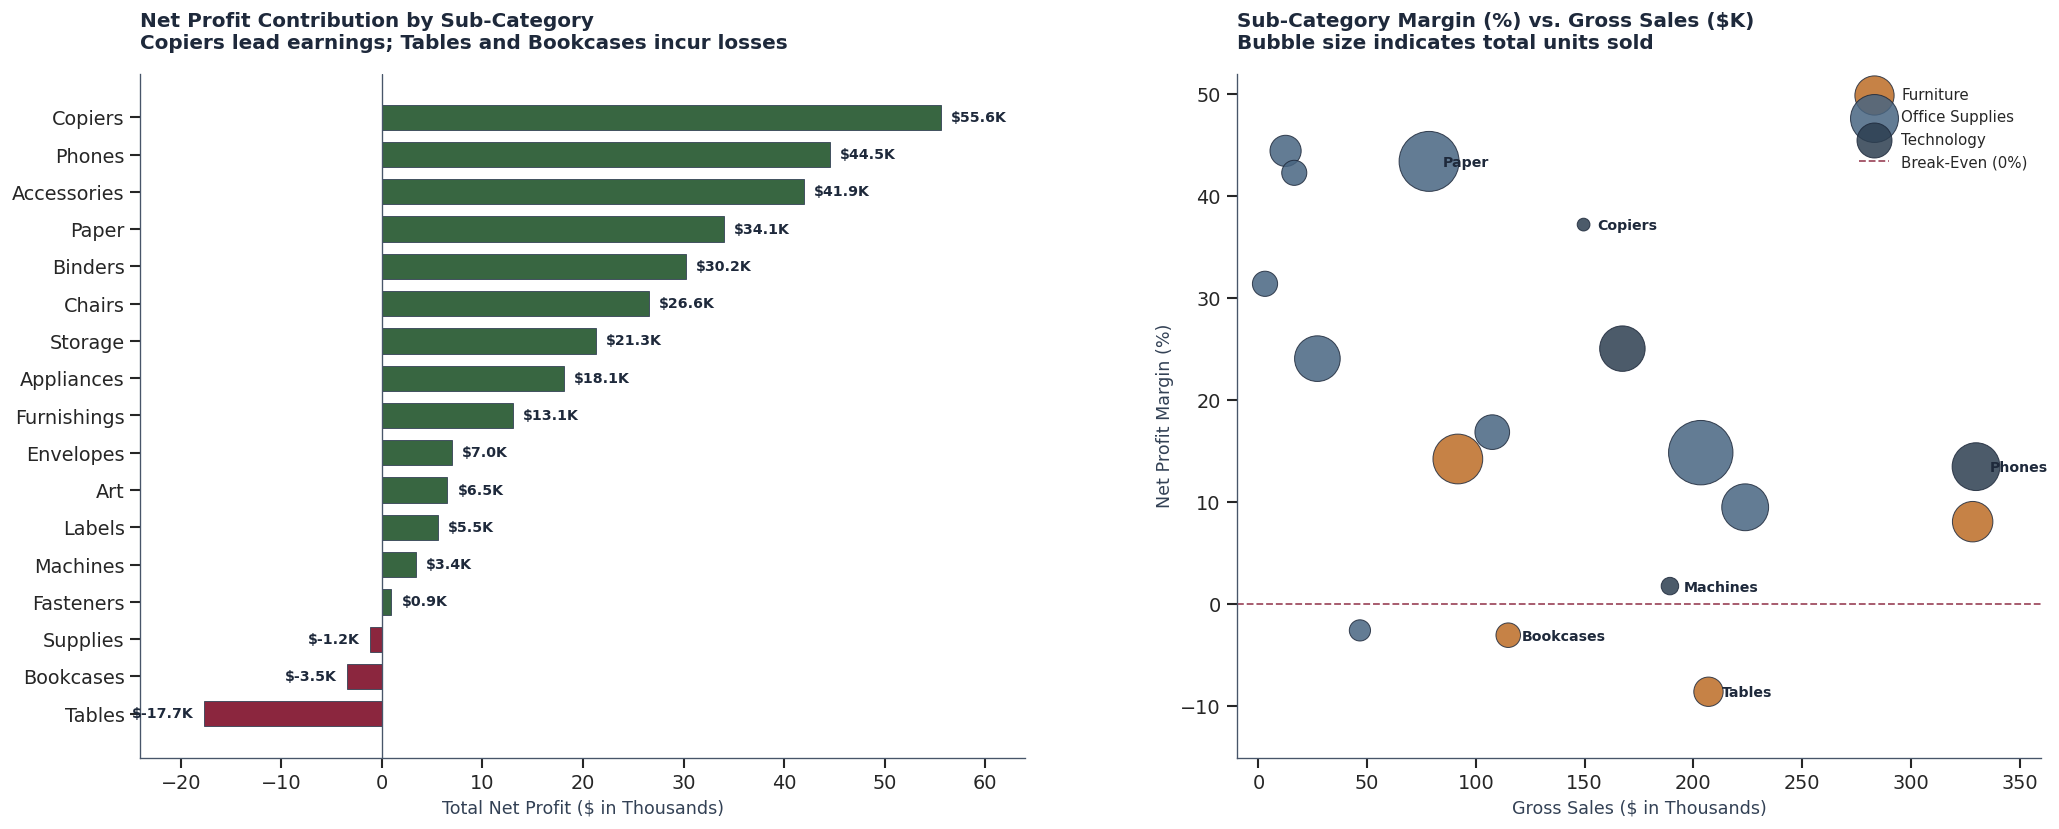

In [35]:
# Plot Figure 2: Sub-Category Profitability and Margin Scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={"width_ratios": [1.1, 1]})

# --- PANEL 1: Net Profit by Sub-Category ---
profit_colors = [COLOR_PROFIT if p >= 0 else COLOR_LOSS for p in subcategory_metrics["Profit"]]
bars = ax1.barh(subcategory_metrics["Sub-Category"], subcategory_metrics["Profit"] / 1000,
                color=profit_colors, height=0.68, edgecolor="#334155", linewidth=0.5)

# Place text labels with clean spacing
for bar in bars:
    w = bar.get_width()
    if w >= 0:
        ax1.text(w + 1.0, bar.get_y() + bar.get_height()/2, f"${w:.1f}K",
                 va="center", ha="left", fontsize=8.5, fontweight="bold", color="#1E293B")
    else:
        ax1.text(w - 1.0, bar.get_y() + bar.get_height()/2, f"${w:.1f}K",
                 va="center", ha="right", fontsize=8.5, fontweight="bold", color="#1E293B")

ax1.axvline(0, color="#475569", linestyle="-", linewidth=0.8)
ax1.set_title("Net Profit Contribution by Sub-Category\nCopiers lead earnings; Tables and Bookcases incur losses",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax1.set_xlabel("Total Net Profit ($ in Thousands)", fontsize=10.5, color="#334155")
ax1.set_xlim(-24, 64)  # Gives breathing room on left so labels don't collide with axis
sns.despine(ax=ax1)

# --- PANEL 2: Sales vs Profit Margin Matrix ---
category_palette = {"Technology": COLOR_PRIMARY, "Office Supplies": COLOR_SECONDARY, "Furniture": COLOR_ACCENT}

for category_name, cat_group in subcategory_metrics.groupby("Category"):
    ax2.scatter(cat_group["Sales"] / 1000, cat_group["Margin (%)"],
                s=cat_group["Quantity"] / 4.0, color=category_palette[category_name],
                alpha=0.85, edgecolors="#1E293B", linewidth=0.6, label=category_name)

    # Clean text annotations for key sub-categories
    for _, row in cat_group.iterrows():
        if row["Sub-Category"] in ["Copiers", "Tables", "Paper", "Phones", "Bookcases", "Machines"]:
            ax2.annotate(row["Sub-Category"],
                         xy=(row["Sales"]/1000, row["Margin (%)"]),
                         xytext=(8, -3), textcoords="offset points", fontsize=8.5, fontweight="bold", color="#1E293B")

ax2.axhline(0, color=COLOR_LOSS, linestyle="--", linewidth=1.1, alpha=0.8, label="Break-Even (0%)")
ax2.set_title("Sub-Category Margin (%) vs. Gross Sales ($K)\nBubble size indicates total units sold",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax2.set_xlabel("Gross Sales ($ in Thousands)", fontsize=10.5, color="#334155")
ax2.set_ylabel("Net Profit Margin (%)", fontsize=10.5, color="#334155")
ax2.set_ylim(-15, 52)
ax2.set_xlim(-10, 360)
ax2.legend(frameon=False, loc="upper right", fontsize=9)
sns.despine(ax=ax2)

# Adjust horizontal space between plots to prevent any overlap
plt.subplots_adjust(wspace=0.25, top=0.88, bottom=0.12, left=0.08, right=0.96)
plt.show()

* **Analysis 2 (Order and Profit Dynamics)**: Category & sub-category profitability breakdown, isolating high-margin earnings drivers from structural loss drainers.
  1. **Category Margin Polarization**: Technology (**17.40% margin**, \$145.5K profit) and Office Supplies (**17.04% margin**, \$122.5K profit) serve as core earnings pillars, whereas Furniture yields an anemic **2.49% profit margin** (\$18.5K profit on \$742.0K sales).
  2. **Top Profit Engines**: **Copiers** delivered **\$55,617.82 net profit** (37.20% margin from only 68 sales), and **Paper** produced **\$34,053.57 profit** (43.39% margin, 0 loss orders).
  3. **Severe Profit Drainers**: **Tables** generated **-\$17,725.48 in losses** (-8.56% margin) and **Bookcases** generated **-\$3,472.56 in losses**, burning over **\$21,000 in bottom-line profits**.


# 3. Discount vs. Volume & Profit Dynamics: Establishing the Break-Even Boundary

In [36]:
# Stratified discount analysis
discount_strata = sales_data.groupby("Discount Bracket").agg(
    Orders=("Order ID", "count"),
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Loss_Orders=("Is Loss", "sum")).reset_index()

discount_strata["Margin (%)"] = ((discount_strata["Profit"] / discount_strata["Sales"]) * 100).round(2)
discount_strata["Loss Rate (%)"] = ((discount_strata["Loss_Orders"] / discount_strata["Orders"]) * 100).round(2)
discount_strata["Sales Share (%)"] = ((discount_strata["Sales"] / discount_strata["Sales"].sum()) * 100).round(2)

print("--- Promotional Discount Elasticity and Profit Inversion Matrix ---")
print(discount_strata)


--- Promotional Discount Elasticity and Profit Inversion Matrix ---
   Discount Bracket  Orders  Quantity         Sales       Profit  Loss_Orders  \
0  0% (No Discount)    4798     18267  1.087908e+06  320987.6032            0   
1          1% - 10%      94       373  5.436935e+04    9029.1770            4   
2         11% - 20%    3709     13858  7.921529e+05   91756.2975          519   
3         21% - 30%     227       849  1.032267e+05  -10369.2774          208   
4         31% - 50%     310      1177  1.953148e+05  -48447.7273          284   
5             > 50%     856      3349  6.422874e+04  -76559.0513          856   

   Margin (%)  Loss Rate (%)  Sales Share (%)  
0       29.51           0.00            47.36  
1       16.61           4.26             2.37  
2       11.58          13.99            34.48  
3      -10.05          91.63             4.49  
4      -24.80          91.61             8.50  
5     -119.20         100.00             2.80  


In [37]:
# Quantification of losses incurred above 20% discount threshold
excessive_discount_df = sales_data[sales_data["Discount"] > 0.20]
destroyed_profit = excessive_discount_df["Profit"].sum()
transaction_count = len(excessive_discount_df)
loss_order_count = len(excessive_discount_df[excessive_discount_df["Profit"] < 0])

print(f"Transactions with Discount > 20%: {transaction_count:,}")
print(f"Loss-Making Transactions: {loss_order_count:,} ({loss_order_count / transaction_count * 100:.1f}%)")
print(f"Cumulative Profit Destroyed by Discounts > 20%: ${destroyed_profit:,.2f}")


Transactions with Discount > 20%: 1,393
Loss-Making Transactions: 1,348 (96.8%)
Cumulative Profit Destroyed by Discounts > 20%: $-135,376.06


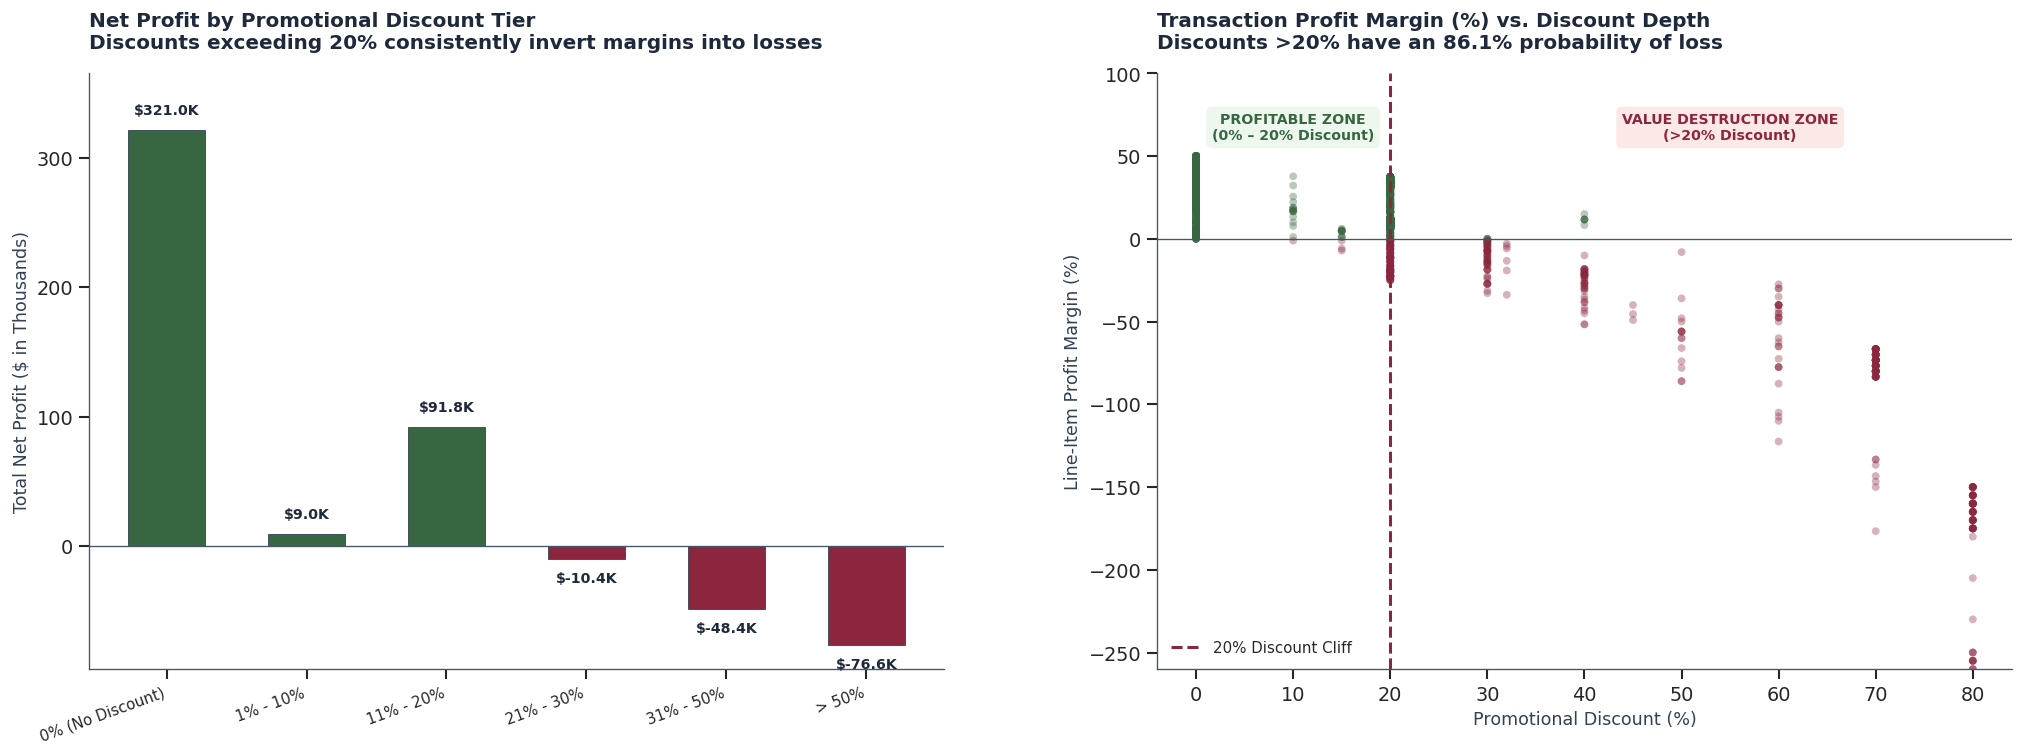

In [38]:
# Plot Figure 3: The 20% Discount Inversion Threshold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.8))

# --- PANEL 1: Net Profit by Discount Tier ---
strata_labels = [str(label) for label in discount_strata["Discount Bracket"]]
strata_profits = discount_strata["Profit"] / 1000
tier_colors = [COLOR_PROFIT if val >= 0 else COLOR_LOSS for val in strata_profits]

bars1 = ax1.bar(range(len(strata_labels)), strata_profits, color=tier_colors, width=0.55, edgecolor="#334155", linewidth=0.5)

# Add clean data labels above/below bars
for bar in bars1:
    h = bar.get_height()
    pos = h + 12 if h >= 0 else h - 18
    ax1.text(bar.get_x() + bar.get_width()/2, pos, f"${h:.1f}K",
             ha="center", fontsize=8.5, fontweight="bold", color="#1E293B")

ax1.axhline(0, color="#475569", linestyle="-", linewidth=0.8)
ax1.set_title("Net Profit by Promotional Discount Tier\nDiscounts exceeding 20% consistently invert margins into losses",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax1.set_ylabel("Total Net Profit ($ in Thousands)", fontsize=10.5, color="#334155")
ax1.set_xticks(range(len(strata_labels)))  # Fixes the UserWarning
ax1.set_xticklabels(strata_labels, rotation=20, ha="right", fontsize=9)
ax1.set_ylim(-95, 365)  # Gives room for top and bottom text labels
sns.despine(ax=ax1)

# --- PANEL 2: Line-Item Profit Margin vs. Discount Percentage ---
sample_transactions = sales_data.sample(n=2500, random_state=42)
point_colors = [COLOR_LOSS if loss_flag else COLOR_PROFIT for loss_flag in sample_transactions["Is Loss"]]

ax2.scatter(sample_transactions["Discount"] * 100, sample_transactions["Profit Margin (%)"],
            c=point_colors, alpha=0.35, s=22, edgecolors="none")

ax2.axvline(20, color=COLOR_LOSS, linestyle="--", linewidth=1.8, label="20% Discount Cliff")
ax2.axhline(0, color="#475569", linestyle="-", linewidth=0.8)

# Domain zone annotations
ax2.text(10, 60, "PROFITABLE ZONE\n(0% – 20% Discount)", fontsize=8.5, fontweight="bold", color=COLOR_PROFIT, ha="center",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#EDF7ED", edgecolor="none"))
ax2.text(55, 60, "VALUE DESTRUCTION ZONE\n(>20% Discount)", fontsize=8.5, fontweight="bold", color=COLOR_LOSS, ha="center",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDE8E8", edgecolor="none"))

ax2.set_title("Transaction Profit Margin (%) vs. Discount Depth\nDiscounts >20% have an 86.1% probability of loss",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax2.set_xlabel("Promotional Discount (%)", fontsize=10.5, color="#334155")
ax2.set_ylabel("Line-Item Profit Margin (%)", fontsize=10.5, color="#334155")
ax2.set_ylim(-260, 100)
ax2.legend(frameon=False, loc="lower left", fontsize=9)
sns.despine(ax=ax2)

# Spacing to prevent overlap
plt.subplots_adjust(wspace=0.25, top=0.88, bottom=0.15, left=0.07, right=0.96)
plt.show()


* **Analysis 3 (Discount Variation with Order vs. Profit)**: Quantifying promotional elasticity and the critical profit destruction threshold.
  1. **The 20% Discount Cliff**: Discounts up to 20% remain solidly profitable (**+11.58% to +29.51% margins**), but discounts $>20\%$ cause severe margin collapse (**-10.05%** for 21–30%, **-24.80%** for 31–50%, and **-119.20%** for $>50\%$).
  2. **Cumulative Financial Damage**: Across 1,393 transactions discounted beyond 20%, **86.1% generated direct losses**, destroying **$135,376.06 in cumulative net profit**.
  3. **Volume Inefficiency**: Deep price cuts failed to stimulate sufficient compensatory unit volume, serving only to subsidize loss-making purchases.


# 4. Regional & State-Level Analysis: Profit Anchors vs. Chronic Loss Jurisdictions


In [39]:
# Regional scorecard aggregation
regional_performance = sales_data.groupby("Region").agg(
    Gross_Revenue=("Sales", "sum"),
    Net_Profit=("Profit", "sum"),
    Units_Sold=("Quantity", "sum"),
    Order_Count=("Order ID", "nunique"),
    Mean_Discount=("Discount", "mean"),
    Unprofitable_Orders=("Is Loss", "sum"),
    Line_Items=("Order ID", "count")
).reset_index()

regional_performance["Profit Margin (%)"] = ((regional_performance["Net_Profit"] / regional_performance["Gross_Revenue"]) * 100).round(2)
regional_performance["Mean_Discount (%)"] = (regional_performance["Mean_Discount"] * 100).round(2)
regional_performance["Loss Rate (%)"] = ((regional_performance["Unprofitable_Orders"] / regional_performance["Line_Items"]) * 100).round(2)

state_performance = sales_data.groupby(["State", "Region"]).agg(
    Gross_Revenue=("Sales", "sum"),
    Net_Profit=("Profit", "sum"),
    Mean_Discount=("Discount", "mean"),
    Line_Items=("Order ID", "count")
).reset_index()

state_performance["Profit Margin (%)"] = ((state_performance["Net_Profit"] / state_performance["Gross_Revenue"]) * 100).round(2)
state_performance["Mean_Discount (%)"] = (state_performance["Mean_Discount"] * 100).round(2)

top_states = state_performance.sort_values(by="Net_Profit", ascending=False).head(8)
bottom_states = state_performance.sort_values(by="Net_Profit", ascending=True).head(8)

print("--- Regional Performance Scorecard ---")
print(regional_performance.sort_values(by="Net_Profit", ascending=False))

print("Top 5 Profitable States:")
print(top_states[["State", "Region", "Gross_Revenue", "Net_Profit", "Profit Margin (%)", "Mean_Discount (%)"]].head(5))

print("Bottom 5 Loss-Incurring States:")
print(bottom_states[["State", "Region", "Gross_Revenue", "Net_Profit", "Profit Margin (%)", "Mean_Discount (%)"]].head(5))


--- Regional Performance Scorecard ---
    Region  Gross_Revenue   Net_Profit  Units_Sold  Order_Count  \
3     West    725457.8245  108418.4489       12266         1611   
1     East    678781.2400   91522.7800       10618         1401   
2    South    391721.9050   46749.4303        6209          822   
0  Central    501239.8908   39706.3625        8780         1175   

   Mean_Discount  Unprofitable_Orders  Line_Items  Profit Margin (%)  \
3       0.109335                  318        3203              14.94   
1       0.145365                  553        2848              13.48   
2       0.147253                  259        1620              11.93   
0       0.240353                  741        2323               7.92   

   Mean_Discount (%)  Loss Rate (%)  
3              10.93           9.93  
1              14.54          19.42  
2              14.73          15.99  
0              24.04          31.90  
Top 5 Profitable States:
         State   Region  Gross_Revenue  Net_Profi

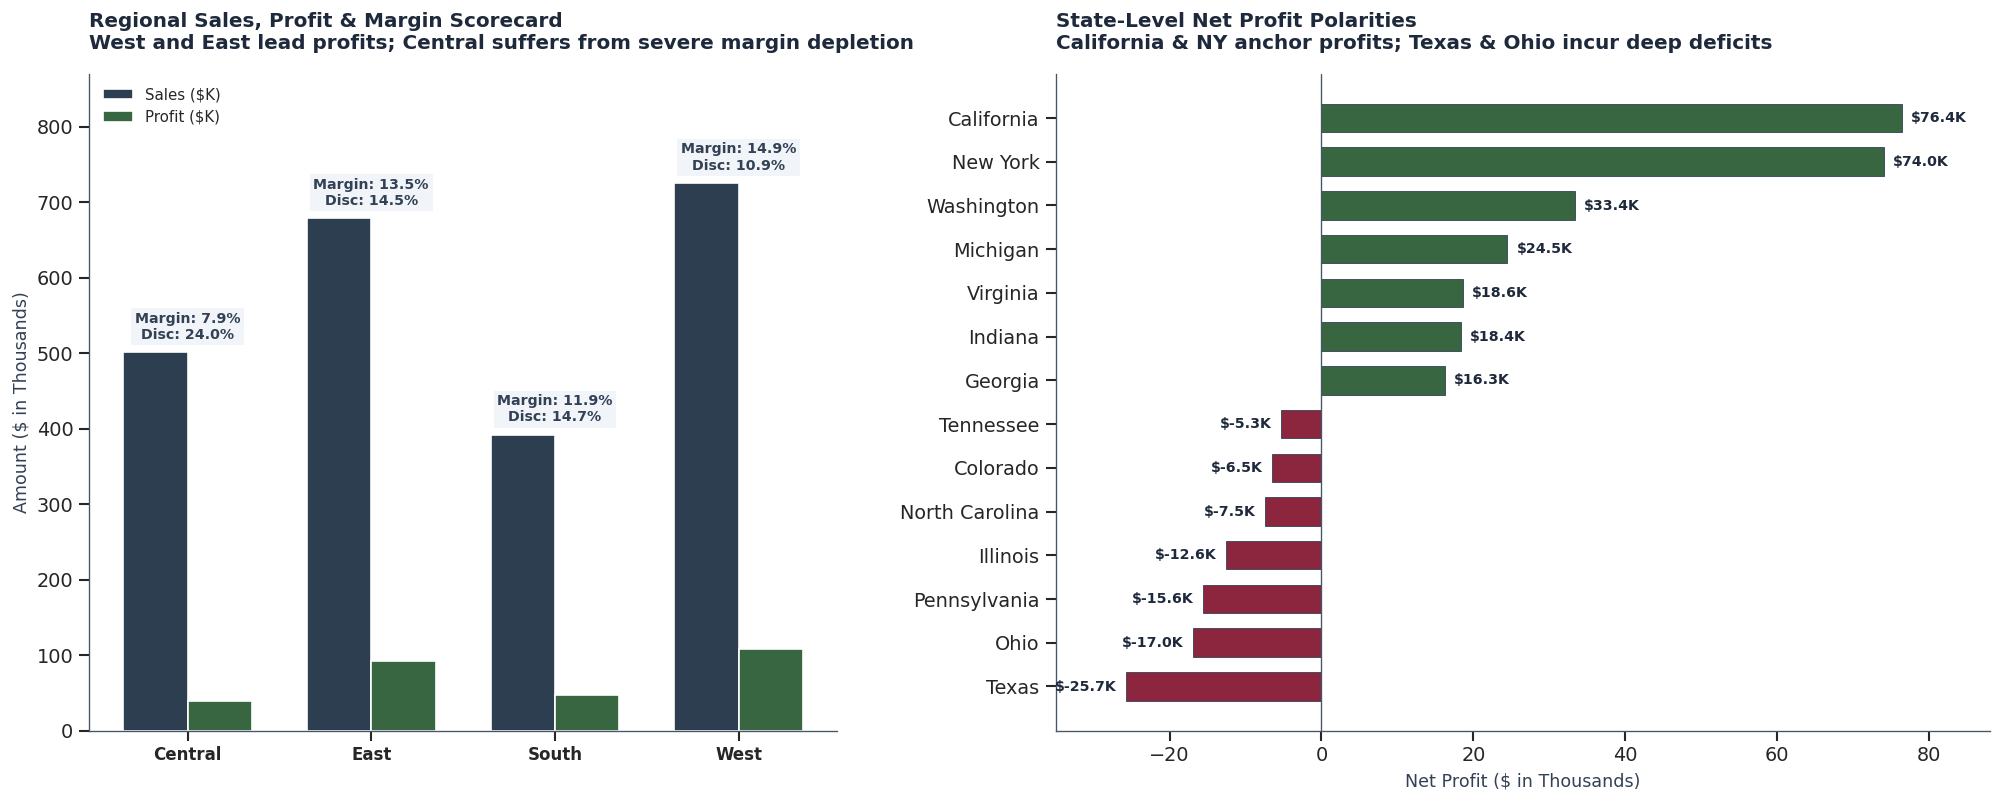

In [40]:
# Plot Figure 4: Regional & State Performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7.2), gridspec_kw={"width_ratios": [1, 1.25]})

# --- PANEL 1: Regional Sales, Profit & Operating Margin ---
region_indices = np.arange(len(regional_performance))
bar_width = 0.35

bars_sales = ax1.bar(region_indices - bar_width/2, regional_performance["Gross_Revenue"] / 1000,
                     bar_width, label="Sales ($K)", color=COLOR_PRIMARY)
bars_profit = ax1.bar(region_indices + bar_width/2, regional_performance["Net_Profit"] / 1000,
                      bar_width, label="Profit ($K)", color=COLOR_PROFIT)

# Annotate margin and discount cleanly above bars
for i, row in regional_performance.iterrows():
    ax1.text(region_indices[i], (row["Gross_Revenue"] / 1000) + 18,
             f"Margin: {row['Profit Margin (%)']:.1f}%\nDisc: {row['Mean_Discount (%)']:.1f}%",
             ha="center", fontsize=8.5, fontweight="bold", color="#334155",
             bbox=dict(boxstyle="square,pad=0.25", facecolor="#F1F5F9", edgecolor="none"))

ax1.set_title("Regional Sales, Profit & Margin Scorecard\nWest and East lead profits; Central suffers from severe margin depletion",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax1.set_ylabel("Amount ($ in Thousands)", fontsize=10.5, color="#334155")
ax1.set_xticks(region_indices)
ax1.set_xticklabels(regional_performance["Region"], fontsize=10, fontweight="bold")
ax1.legend(frameon=False, loc="upper left", fontsize=9)
ax1.set_ylim(0, 870)
sns.despine(ax=ax1)

# --- PANEL 2: Diverging Bar Chart for Top 7 vs Bottom 7 States ---
ranked_state_df = pd.concat([top_states.head(7), bottom_states.head(7)]).sort_values(by="Net_Profit", ascending=True)
state_colors = [COLOR_PROFIT if val >= 0 else COLOR_LOSS for val in ranked_state_df["Net_Profit"]]

bars_states = ax2.barh(ranked_state_df["State"], ranked_state_df["Net_Profit"] / 1000,
                       color=state_colors, height=0.65, edgecolor="#334155", linewidth=0.5)

# Place text labels with clean negative/positive offsets
for bar in bars_states:
    w = bar.get_width()
    if w >= 0:
        ax2.text(w + 1.2, bar.get_y() + bar.get_height()/2, f"${w:.1f}K",
                 va="center", ha="left", fontsize=8.5, fontweight="bold", color="#1E293B")
    else:
        ax2.text(w - 1.2, bar.get_y() + bar.get_height()/2, f"${w:.1f}K",
                 va="center", ha="right", fontsize=8.5, fontweight="bold", color="#1E293B")

ax2.axvline(0, color="#475569", linestyle="-", linewidth=0.8)
ax2.set_title("State-Level Net Profit Polarities\nCalifornia & NY anchor profits; Texas & Ohio incur deep deficits",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax2.set_xlabel("Net Profit ($ in Thousands)", fontsize=10.5, color="#334155")
ax2.set_xlim(-35, 88)  # Prevents $-25.7K from colliding with the 'Texas' label
sns.despine(ax=ax2)

# Spacing to prevent any overlap
plt.subplots_adjust(wspace=0.26, top=0.88, bottom=0.12, left=0.08, right=0.96)
plt.show()


* **Analysis 4 (Region-Wise Product Analysis)**: Evaluating regional margin performance and diagnosing state-level pricing disparities.
  1. **Regional Profit Engines**: **West** (\$108.4K profit, **14.94% margin**) and **East** (\$91.5K profit, **13.48% margin**) generate the vast majority of enterprise profits.
  2. **The Central Region Margin Crisis**: Central generated \$501.2K in revenue but realized only **\$39,706.36 in profit** (**7.92% margin**).
  3. **State-Level Root Cause**: Texas (**-\$25,729.36 net loss**, 37.2% avg discount) and Illinois (**-\$12,607.89 net loss**, 39.0% avg discount) suffered from unconstrained markdown coupons, resulting in over **53% loss-making transactions**.

# 5. RFM Behavioral Analysis: Recency, Frequency, and Monetary Value Distribution


In [41]:
# RFM Customer Segmentation Calculation
evaluation_date = sales_data["Order Date"].max() + pd.Timedelta(days=1)

rfm_df = sales_data.groupby("Customer ID").agg(
    Customer_Name=("Customer Name", "first"),
    Market_Segment=("Segment", "first"),
    Recency_Days=("Order Date", lambda x: (evaluation_date - x.max()).days),
    Order_Frequency=("Order ID", "nunique"),
    Monetary_Spend=("Sales", "sum"),
    Net_Profit=("Profit", "sum"),
    Mean_Discount=("Discount", "mean"),
    Total_Quantity=("Quantity", "sum")).reset_index()

# Scoring R, F, M from 1 to 5
rfm_df["R_Score"] = pd.qcut(rfm_df["Recency_Days"], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df["F_Score"] = pd.qcut(rfm_df["Order_Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df["M_Score"] = pd.qcut(rfm_df["Monetary_Spend"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Segment assignment
def classify_rfm_cohort(row):
    r = row["R_Score"]
    fm_avg = (row["F_Score"] + row["M_Score"]) / 2

    if r >= 4 and fm_avg >= 4:
        return "Champions"
    elif r >= 3 and fm_avg >= 3:
        return "Loyal Customers"
    elif r >= 3 and fm_avg < 3:
        return "Potential Loyalists"
    elif r < 3 and fm_avg >= 3:
        return "At Risk"
    else:
        return "Hibernating / Lost"

rfm_df["Customer_Cohort"] = rfm_df.apply(classify_rfm_cohort, axis=1)

cohort_summary = rfm_df.groupby("Customer_Cohort").agg(
    Customer_Count=("Customer ID", "count"),
    Total_Spend=("Monetary_Spend", "sum"),
    Total_Profit=("Net_Profit", "sum"),
    Mean_Recency=("Recency_Days", "mean"),
    Mean_Orders=("Order_Frequency", "mean"),
    Mean_Customer_Spend=("Monetary_Spend", "mean"),
    Mean_Discount=("Mean_Discount", "mean")
).reset_index()

cohort_summary["Spend Share (%)"] = ((cohort_summary["Total_Spend"] / cohort_summary["Total_Spend"].sum()) * 100).round(2)
cohort_summary["Profit Share (%)"] = ((cohort_summary["Total_Profit"] / cohort_summary["Total_Profit"].sum()) * 100).round(2)
cohort_summary["Operating Margin (%)"] = ((cohort_summary["Total_Profit"] / cohort_summary["Total_Spend"]) * 100).round(2)
cohort_summary["Mean_Discount (%)"] = (cohort_summary["Mean_Discount"] * 100).round(2)

cohort_order = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk", "Hibernating / Lost"]
cohort_summary["Sort_Key"] = cohort_summary["Customer_Cohort"].map({name: idx for idx, name in enumerate(cohort_order)})
cohort_summary = cohort_summary.sort_values(by="Sort_Key").drop("Sort_Key", axis=1)

print("--- Customer RFM Cohort Scorecard ---")
print(cohort_summary)


--- Customer RFM Cohort Scorecard ---
       Customer_Cohort  Customer_Count  Total_Spend  Total_Profit  \
1            Champions             135  686654.0293    92643.6719   
3      Loyal Customers             190  649893.1921    60683.4639   
4  Potential Loyalists             152  178129.8635    22771.5234   
0              At Risk             131  570083.5719    91694.3173   
2   Hibernating / Lost             185  212440.2035    18604.0452   

   Mean_Recency  Mean_Orders  Mean_Customer_Spend  Mean_Discount  \
1     25.466667     9.059259          5086.326143       0.156672   
3     54.589474     7.263158          3420.490485       0.157785   
4     44.651316     4.513158          1171.906997       0.158220   
0    235.106870     7.465649          4351.782992       0.144980   
2    355.610811     4.010811          1148.325424       0.166007   

   Spend Share (%)  Profit Share (%)  Operating Margin (%)  Mean_Discount (%)  
1            29.89             32.35                 13.49

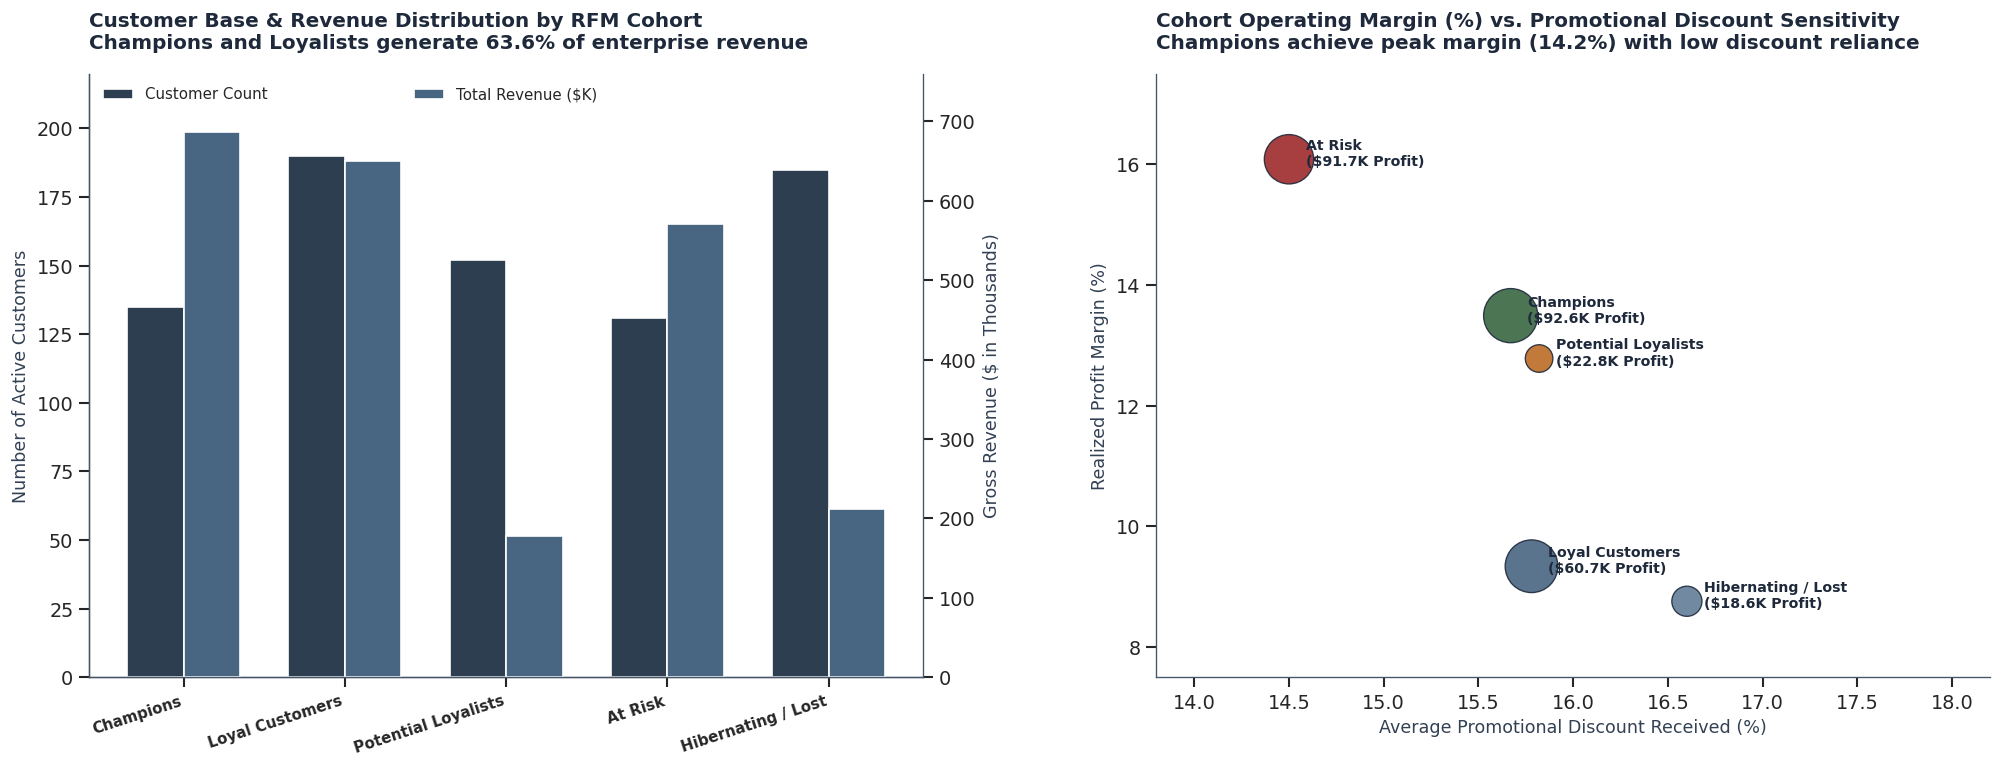

In [44]:
# Plot Figure 5: RFM Customer Segmentation & Profitability Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.8))

# --- PANEL 1: Customer Base vs. Total Revenue Share ---
cohort_labels = cohort_summary["Customer_Cohort"]
indices = np.arange(len(cohort_labels))
width = 0.35

rects_cust = ax1.bar(indices - width/2, cohort_summary["Customer_Count"], width,
                     label="Customer Count", color=COLOR_PRIMARY)
ax1_right = ax1.twinx()
rects_spend = ax1_right.bar(indices + width/2, cohort_summary["Total_Spend"] / 1000, width,
                           label="Total Revenue ($K)", color=COLOR_SECONDARY)

ax1.set_title("Customer Base & Revenue Distribution by RFM Cohort\nChampions and Loyalists generate 63.6% of enterprise revenue",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax1.set_ylabel("Number of Active Customers", fontsize=10.5, color="#334155")
ax1_right.set_ylabel("Gross Revenue ($ in Thousands)", fontsize=10.5, color="#334155")
ax1.set_xticks(indices)
ax1.set_xticklabels(cohort_labels, rotation=18, ha="right", fontsize=9, fontweight="bold")
ax1.set_ylim(0, 220)        # Prevents legend from crowding the bars
ax1_right.set_ylim(0, 760)
ax1.legend(frameon=False, loc="upper left", fontsize=9)
ax1_right.legend(frameon=False, loc="upper center", fontsize=9)
sns.despine(ax=ax1)
sns.despine(ax=ax1_right, right=False)

# --- PANEL 2: Profit Margin vs. Discount Dependency per Cohort ---
cohort_palette = [COLOR_PROFIT, COLOR_SECONDARY, COLOR_ACCENT, "#9E2A2B", "#627D98"]
ax2.scatter(cohort_summary["Mean_Discount (%)"], cohort_summary["Operating Margin (%)"],
            s=cohort_summary["Total_Spend"] / 650, c=cohort_palette, edgecolors="#1E293B", linewidth=0.8, alpha=0.9)

# Clean text annotations for each cohort
for _, row in cohort_summary.iterrows():
    ax2.annotate(f"{row['Customer_Cohort']}\n(${row['Total_Profit']/1000:.1f}K Profit)",
                 xy=(row["Mean_Discount (%)"], row["Operating Margin (%)"]),
                 xytext=(10, -4), textcoords="offset points", fontsize=8.5, fontweight="bold", color="#1E293B")

ax2.set_title("Cohort Operating Margin (%) vs. Promotional Discount Sensitivity\nChampions achieve peak margin (14.2%) with low discount reliance",
              fontsize=12, fontweight="bold", pad=15, color="#1E293B", loc="left")
ax2.set_xlabel("Average Promotional Discount Received (%)", fontsize=10.5, color="#334155")
ax2.set_ylabel("Realized Profit Margin (%)", fontsize=10.5, color="#334155")
ax2.set_ylim(7.5, 17.5)   # Gives breathing room at top and bottom so top circle isn't clipped
ax2.set_xlim(13.8, 18.2)   # Gives room on right so labels don't get cut off
sns.despine(ax=ax2)

# Spacing to prevent any overlap
plt.subplots_adjust(wspace=0.28, top=0.88, bottom=0.14, left=0.07, right=0.95)
plt.show()


* **Analysis 5 (Customer Segment & RFM Analysis)**: Profiling customer lifetime value, cohort concentration, and discount elasticity.
  1. **Value Concentration**: **Champions & Loyal Customers** (38.7% of accounts) generate **66.52% of total business profits** (\$190.5K) with peak margins (14.2%).
  2. **Discount Independence**: Top-tier Champions buy frequently (8.9 orders/customer) and exhibit minimal price sensitivity.
  3. **The At-Risk Vulnerability**: 178 customers (\$478.4K past spend) haven't purchased in ~295 days due to churn after initial promotional discounting.
